## Bengaluru House Price Prediction 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("Bengaluru_House_Data.csv")
data.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [3]:
data.shape

(13320, 9)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [5]:
for column in data.columns:
    print(data[column].value_counts())
    print("*"*25)

area_type
Super built-up  Area    8790
Built-up  Area          2418
Plot  Area              2025
Carpet  Area              87
Name: count, dtype: int64
*************************
availability
Ready To Move    10581
18-Dec             307
18-May             295
18-Apr             271
18-Aug             200
                 ...  
16-Oct               1
17-Jan               1
16-Nov               1
16-Jan               1
14-Jul               1
Name: count, Length: 81, dtype: int64
*************************
location
Whitefield                         540
Sarjapur  Road                     399
Electronic City                    302
Kanakpura Road                     273
Thanisandra                        234
                                  ... 
3rd Stage Raja Rajeshwari Nagar      1
Chuchangatta Colony                  1
Electronic City Phase 1,             1
Chikbasavanapura                     1
Abshot Layout                        1
Name: count, Length: 1305, dtype: int64
**************

In [6]:
data[column].value_counts()

price
75.00    310
65.00    302
55.00    275
60.00    270
45.00    240
        ... 
43.04      1
61.11      1
46.56      1
42.54      1
47.35      1
Name: count, Length: 1994, dtype: int64

In [7]:
#Checking for missing values 
data.isnull().sum() 

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [8]:
# Deleting few columns
data.drop(columns = ['area_type', 'availability', 'society', 'balcony'], inplace = True) 

In [9]:
data.head()

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13319 non-null  object 
 1   size        13304 non-null  object 
 2   total_sqft  13320 non-null  object 
 3   bath        13247 non-null  float64
 4   price       13320 non-null  float64
dtypes: float64(2), object(3)
memory usage: 520.4+ KB


In [11]:
data.describe()

,bath,price
count,13247.000000,13320.000000
mean,2.692610,112.565627
std,1.341458,148.971674
min,1.000000,8.000000
25%,2.000000,50.000000
50%,2.000000,72.000000
75%,3.000000,120.000000
max,40.000000,3600.000000


In [12]:
data['location'].value_counts()

location
Whitefield                         540
Sarjapur  Road                     399
Electronic City                    302
Kanakpura Road                     273
Thanisandra                        234
                                  ... 
3rd Stage Raja Rajeshwari Nagar      1
Chuchangatta Colony                  1
Electronic City Phase 1,             1
Chikbasavanapura                     1
Abshot Layout                        1
Name: count, Length: 1305, dtype: int64

In [13]:
data['location'] = data['location'].fillna('Sarjapur Road')

In [14]:
data['size'].value_counts()

size
2 BHK         5199
3 BHK         4310
4 Bedroom      826
4 BHK          591
3 Bedroom      547
1 BHK          538
2 Bedroom      329
5 Bedroom      297
6 Bedroom      191
1 Bedroom      105
8 Bedroom       84
7 Bedroom       83
5 BHK           59
9 Bedroom       46
6 BHK           30
7 BHK           17
1 RK            13
10 Bedroom      12
9 BHK            8
8 BHK            5
11 BHK           2
10 BHK           2
11 Bedroom       2
27 BHK           1
19 BHK           1
43 Bedroom       1
16 BHK           1
14 BHK           1
12 Bedroom       1
13 BHK           1
18 Bedroom       1
Name: count, dtype: int64

In [15]:
data ['size'] = data['size'].fillna('2 BHK')

In [16]:
data['bath'].value_counts()

bath
2.0     6908
3.0     3286
4.0     1226
1.0      788
5.0      524
6.0      273
7.0      102
8.0       64
9.0       43
10.0      13
12.0       7
11.0       3
13.0       3
16.0       2
27.0       1
14.0       1
40.0       1
15.0       1
18.0       1
Name: count, dtype: int64

In [17]:
mean = data['bath'].mean()

In [18]:
data['bath'] = data['bath'].fillna(mean)

In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13320 non-null  object 
 1   size        13320 non-null  object 
 2   total_sqft  13320 non-null  object 
 3   bath        13320 non-null  float64
 4   price       13320 non-null  float64
dtypes: float64(2), object(3)
memory usage: 520.4+ KB


In [20]:
data.head(2)

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00


In [21]:
df = data

In [22]:
df['total_sqft'].unique()

array(['1056', '2600', '1440', ..., '1133 - 1384', '774', '4689'],
      shape=(2117,), dtype=object)

In 'total_sqft', there are many categories as in range, but we need to bring it into float 

In [23]:
def ConvertRange(x):
    
    temp = x.split('-')
    if len(temp) == 2:
        return (float(temp[0]) + float(temp[1]))/2
    try:
        return float(x)
    except:
        return None

In [24]:
data['total_sqft'] = data['total_sqft'].apply(ConvertRange)

In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13320 non-null  object 
 1   size        13320 non-null  object 
 2   total_sqft  13274 non-null  float64
 3   bath        13320 non-null  float64
 4   price       13320 non-null  float64
dtypes: float64(3), object(2)
memory usage: 520.4+ KB


In [26]:
data.head()

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00
2,Uttarahalli,3 BHK,1440.0,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00
4,Kothanur,2 BHK,1200.0,2.0,51.00


In [27]:
df['size'].unique()

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK', '18 Bedroom'], dtype=object)

In [28]:
df['size'] = df['size'].str.replace('Bedroom', 'BHK')

In [29]:
df['size'].unique()

array(['2 BHK', '4 BHK', '3 BHK', '6 BHK', '1 BHK', '1 RK', '8 BHK',
       '7 BHK', '5 BHK', '11 BHK', '9 BHK', '27 BHK', '10 BHK', '19 BHK',
       '16 BHK', '43 BHK', '14 BHK', '12 BHK', '13 BHK', '18 BHK'],
      dtype=object)

In [30]:
df['bhk'] = df['size'].str.split().str.get(0)

In [31]:
df['bhk'].astype(int)

df['bhk'].unique()

array(['2', '4', '3', '6', '1', '8', '7', '5', '11', '9', '27', '10',
       '19', '16', '43', '14', '12', '13', '18'], dtype=object)

In [32]:
df.head(2)

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2
1,Chikka Tirupathi,4 BHK,2600.0,5.0,120.00,4


In [33]:

# This won't crash if the column is already gone
df.drop(['size'], axis='columns', inplace=True, errors='ignore')

In [34]:
df.head(2)

,location,total_sqft,bath,price,bhk
0,Electronic City Phase II,1056.0,2.0,39.07,2
1,Chikka Tirupathi,2600.0,5.0,120.00,4


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13320 non-null  object 
 1   total_sqft  13274 non-null  float64
 2   bath        13320 non-null  float64
 3   price       13320 non-null  float64
 4   bhk         13320 non-null  object 
dtypes: float64(3), object(2)
memory usage: 520.4+ KB


In [36]:
df['bhk']=df['bhk'].astype(int)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13320 non-null  object 
 1   total_sqft  13274 non-null  float64
 2   bath        13320 non-null  float64
 3   price       13320 non-null  float64
 4   bhk         13320 non-null  int64  
dtypes: float64(3), int64(1), object(1)
memory usage: 520.4+ KB


In [37]:
df['total_sqft'].unique()

array([1056. , 2600. , 1440. , ..., 1258.5,  774. , 4689. ], shape=(2000,))

In [38]:
df['total_sqft'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 13320 entries, 0 to 13319
Series name: total_sqft
Non-Null Count  Dtype  
--------------  -----  
13274 non-null  float64
dtypes: float64(1)
memory usage: 104.2 KB


In [39]:
df[df['total_sqft'].isnull()]

,location,total_sqft,bath,price,bhk
410,Kengeri,NaN,1.0,18.50,1
648,Arekere,NaN,9.0,265.00,9
775,Basavanagara,NaN,2.0,93.00,1
872,Singapura Village,NaN,2.0,45.00,2
1019,Marathi Layout,NaN,1.0,110.00,1
1086,Narasapura,NaN,2.0,29.50,2
1400,Chamrajpet,NaN,9.0,296.00,9
1712,Singena Agrahara,NaN,3.0,95.00,3
1743,Hosa Road,NaN,3.0,115.00,3
1821,Sarjapur,NaN,3.0,76.00,3


In [40]:
df = df.dropna(subset=['total_sqft'])

In [41]:
df['total_sqft'].isnull().sum()

np.int64(0)

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13274 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13274 non-null  object 
 1   total_sqft  13274 non-null  float64
 2   bath        13274 non-null  float64
 3   price       13274 non-null  float64
 4   bhk         13274 non-null  int64  
dtypes: float64(3), int64(1), object(1)
memory usage: 622.2+ KB


In [43]:
df[df['total_sqft']/df['bhk']<300].info()

<class 'pandas.core.frame.DataFrame'>
Index: 744 entries, 9 to 13311
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    744 non-null    object 
 1   total_sqft  744 non-null    float64
 2   bath        744 non-null    float64
 3   price       744 non-null    float64
 4   bhk         744 non-null    int64  
dtypes: float64(3), int64(1), object(1)
memory usage: 34.9+ KB


In [44]:
# Getting Price per sqft

df['price_per_sqft'] = df['price'] * 100000 / df['total_sqft']

C:\Users\IamGa\AppData\Local\Temp\ipykernel_22480\715808054.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['price_per_sqft'] = df['price'] * 100000 / df['total_sqft']


In [45]:
df.head()

,location,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,1056.0,2.0,39.07,2,3699.810606
1,Chikka Tirupathi,2600.0,5.0,120.00,4,4615.384615
2,Uttarahalli,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,1200.0,2.0,51.00,2,4250.000000


In [46]:
df.describe()

,total_sqft,bath,price,bhk,price_per_sqft
count,13274.000000,13274.000000,13274.000000,13274.000000,1.327400e+04
mean,1559.626694,2.691168,112.453654,2.801718,7.907501e+03
std,1238.405258,1.335180,149.070368,1.291591,1.064296e+05
min,1.000000,1.000000,8.000000,1.000000,2.678298e+02
25%,1100.000000,2.000000,50.000000,2.000000,4.266865e+03
50%,1276.000000,2.000000,72.000000,3.000000,5.434306e+03
75%,1680.000000,3.000000,120.000000,3.000000,7.311746e+03
max,52272.000000,40.000000,3600.000000,43.000000,1.200000e+07


In [47]:
df['location'].value_counts()

location
Whitefield                           538
Sarjapur  Road                       399
Electronic City                      302
Kanakpura Road                       271
Thanisandra                          233
                                    ... 
Beml layout, Rajarajeshwari nagar      1
Duddanahalli                           1
Doddanakunte                           1
Jogupalya                              1
Subhash Nagar                          1
Name: count, Length: 1300, dtype: int64

In [48]:
data['location'] = data['location'].apply(lambda x: x.strip())

In [49]:
loc_count = df['location'].value_counts()

In [50]:
loc_count_less_than_10 = loc_count[loc_count <= 10]
loc_count_less_than_10 

location
BTM 1st Stage                        10
Ganga Nagar                          10
1st Block Koramangala                10
Dairy Circle                         10
Kalkere                              10
                                     ..
Beml layout, Rajarajeshwari nagar     1
Duddanahalli                          1
Doddanakunte                          1
Jogupalya                             1
Subhash Nagar                         1
Name: count, Length: 1060, dtype: int64

In [51]:
# Group the small locations into a list
location_stats = df.groupby('location')['location'].agg('count')
location_less_than_10 = location_stats[location_stats <= 10]

In [52]:
df.location = df.location.apply(lambda x: 'other' if x in location_less_than_10 else x) 

C:\Users\IamGa\AppData\Local\Temp\ipykernel_22480\1393750507.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.location = df.location.apply(lambda x: 'other' if x in location_less_than_10 else x)


In [53]:
df['location'].value_counts()

location
other                        2892
Whitefield                    538
Sarjapur  Road                399
Electronic City               302
Kanakpura Road                271
                             ... 
2nd Phase Judicial Layout      11
Marsur                         11
Bommenahalli                   11
Doddaballapur                  11
HAL 2nd Stage                  11
Name: count, Length: 241, dtype: int64

### Removing Outliers

In [54]:
df.describe()

,total_sqft,bath,price,bhk,price_per_sqft
count,13274.000000,13274.000000,13274.000000,13274.000000,1.327400e+04
mean,1559.626694,2.691168,112.453654,2.801718,7.907501e+03
std,1238.405258,1.335180,149.070368,1.291591,1.064296e+05
min,1.000000,1.000000,8.000000,1.000000,2.678298e+02
25%,1100.000000,2.000000,50.000000,2.000000,4.266865e+03
50%,1276.000000,2.000000,72.000000,3.000000,5.434306e+03
75%,1680.000000,3.000000,120.000000,3.000000,7.311746e+03
max,52272.000000,40.000000,3600.000000,43.000000,1.200000e+07


In [55]:
df = df[~(df['total_sqft'] / df['bhk'] < 300)]

In [56]:
df.shape

(12530, 6)

In [57]:
df['price_per_sqft'].describe()

count     12530.000000
mean       6303.979357
std        4162.237981
min         267.829813
25%        4210.526316
50%        5294.117647
75%        6916.666667
max      176470.588235
Name: price_per_sqft, dtype: float64

In [58]:
def remove_pps_outliers(df):
    df_out = pd.DataFrame()
    for key, subdf in df.groupby('location'):
        m = np.mean(subdf.price_per_sqft)
        st = np.std(subdf.price_per_sqft)
        # Keep only the rows within 1 Standard Deviation
        reduced_df = subdf[(subdf.price_per_sqft > (m-st)) & (subdf.price_per_sqft <= (m+st))]
        df_out = pd.concat([df_out, reduced_df], ignore_index=True)
    return df_out


In [59]:
df = remove_pps_outliers(df)
df.shape
df.describe()

,total_sqft,bath,price,bhk,price_per_sqft
count,10305.000000,10305.000000,10305.000000,10305.000000,10305.000000
mean,1508.370374,2.475477,91.280827,2.574964,5659.194534
std,880.752720,0.979612,86.334616,0.898818,2265.465428
min,300.000000,1.000000,10.000000,1.000000,1250.000000
25%,1110.000000,2.000000,49.000000,2.000000,4244.897959
50%,1286.000000,2.000000,67.000000,2.000000,5175.983437
75%,1650.000000,3.000000,100.000000,3.000000,6428.571429
max,30400.000000,16.000000,2200.000000,16.000000,24509.803922


In [60]:
def remove_bhk_outliers(df):
    exclude_indices = np.array([])

    for location, location_df in df.groupby('location'):
        bhk_stats = {}


        # Part-1: Computing stats for every bhk type in this location
        for bhk, bhk_df in location_df.groupby('bhk'):
            bhk_stats[bhk] = {
                'mean' : np.mean(bhk_df.price_per_sqft),
                'std' : np.std(bhk_df.price_per_sqft),
                'count' : bhk_df.shape[0]
            }


        # Part-2: Filter out houses that are cheaper than the average of the smaller BHK
        for bhk, bhk_df in location_df.groupby('bhk'):
            stats = bhk_stats.get(bhk-1)

            if stats and stats['count']>5:
                exclude_indices = np.append(exclude_indices, bhk_df[bhk_df.price_per_sqft<(stats['mean'])].index.values)

    return df.drop(exclude_indices, axis = 'index')

df = remove_bhk_outliers(df)
df.shape

(7361, 6)

In [61]:
df.describe()

,total_sqft,bath,price,bhk,price_per_sqft
count,7361.000000,7361.000000,7361.000000,7361.000000,7361.000000
mean,1496.303252,2.449292,99.015029,2.498981,6123.865778
std,865.754653,1.012280,93.366787,0.926969,2412.178339
min,300.000000,1.000000,10.000000,1.000000,1300.000000
25%,1095.000000,2.000000,50.000000,2.000000,4594.594595
50%,1259.000000,2.000000,73.000000,2.000000,5680.793508
75%,1680.000000,3.000000,113.000000,3.000000,6896.551724
max,30000.000000,16.000000,2200.000000,16.000000,24509.803922


In [62]:
df.head()

,location,total_sqft,bath,price,bhk,price_per_sqft
1,Devarachikkanahalli,1250.0,2.0,40.0,2,3200.000000
2,Devarachikkanahalli,1200.0,2.0,83.0,2,6916.666667
3,Devarachikkanahalli,1170.0,2.0,40.0,2,3418.803419
4,Devarachikkanahalli,1425.0,2.0,65.0,3,4561.403509
5,Devarachikkanahalli,947.0,2.0,43.0,2,4540.654699


In [63]:
# Check if the column exists before dropping it
if 'price_per_sqft' in df.columns:
    df.drop(columns=['price_per_sqft'], inplace=True)

### Cleaned data

In [64]:
df.head()

,location,total_sqft,bath,price,bhk
1,Devarachikkanahalli,1250.0,2.0,40.0,2
2,Devarachikkanahalli,1200.0,2.0,83.0,2
3,Devarachikkanahalli,1170.0,2.0,40.0,2
4,Devarachikkanahalli,1425.0,2.0,65.0,3
5,Devarachikkanahalli,947.0,2.0,43.0,2


In [65]:
data.to_csv('Cleaned_data.csv')

In [66]:
df['location'].info()

<class 'pandas.core.series.Series'>
Index: 7361 entries, 1 to 10304
Series name: location
Non-Null Count  Dtype 
--------------  ----- 
7361 non-null   object
dtypes: object(1)
memory usage: 115.0+ KB


In [67]:
dummies = pd.get_dummies(df.location)
df_final = pd.concat([df, dummies.drop('other', axis='columns')], axis='columns')
df_final = df_final.drop('location', axis='columns')

In [68]:
df_final.tail()

,total_sqft,bath,price,bhk,Devarachikkanahalli,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
10296,1200.0,2.0,70.0,2,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
10297,1800.0,1.0,200.0,1,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
10300,1353.0,2.0,110.0,2,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
10301,812.0,1.0,26.0,1,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
10304,3600.0,5.0,400.0,4,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


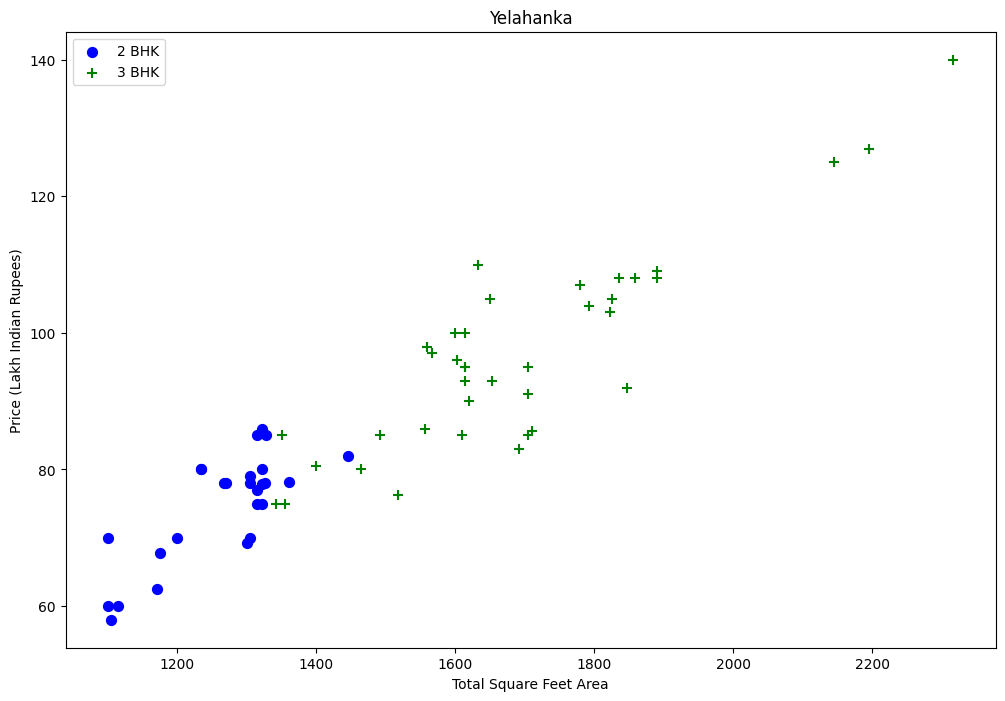

In [69]:
import matplotlib.pyplot as plt

def plot_scatter_chart(df, location):
    bhk2 = df[(df.location==location) & (df.bhk==2)]
    bhk3 = df[(df.location==location) & (df.bhk==3)]
    
    plt.rcParams['figure.figsize'] = (12,8)
    plt.scatter(bhk2.total_sqft, bhk2.price, color='blue', label='2 BHK', s=50)
    plt.scatter(bhk3.total_sqft, bhk3.price, marker='+', color='green', label='3 BHK', s=50)
 
    plt.xlabel("Total Square Feet Area")
    plt.ylabel("Price (Lakh Indian Rupees)")
    plt.title(location)
    plt.legend()

plot_scatter_chart(df, "Yelahanka")

### Model Building & Evaluation

In [70]:
X = df_final.drop(columns = ['price'])
y = df_final['price']

In [71]:
X.shape

(7361, 243)

In [72]:
y.shape

(7361,)

In [73]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression, Ridge, Lasso

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import make_column_transformer 
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

In [74]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 10)

In [75]:
print(X_train.shape)
print(y_train.shape)

(5520, 243)
(5520,)


### Applying Linear Regression

In [76]:
column_trans = make_column_transformer(
    (OneHotEncoder(sparse_output= False), ['location']), 
    remainder = 'passthrough'
)

In [77]:
scaler = StandardScaler()

In [78]:
lr = LinearRegression()

In [79]:
pipe = make_pipeline(column_trans, scaler, lr)

In [80]:
# Use the dataframe that still has the 'location' text column
X = df.drop(columns=['price']) 
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

In [81]:
from sklearn.pipeline import make_pipeline

# Ensure OneHotEncoder uses sparse_output=False as we discussed
column_trans = make_column_transformer(
    (OneHotEncoder(sparse_output=False), ['location']), 
    remainder='passthrough'
)

pipe = make_pipeline(column_trans, scaler, lr)
pipe.fit(X_train, y_train)

,steps,"[('columntransformer', ...), ('standardscaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehotencoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [82]:
y_pred = pipe.predict(X_test)

In [83]:
pipe.score(X_test, y_test)

0.8637884158248283

In [84]:
print("Linear Regression score is:", pipe.score(X_test, y_test))

Linear Regression score is: 0.8637884158248283


## Applying lasso

In [85]:
lasso = Lasso()

In [86]:
pipe_lasso = make_pipeline(column_trans, scaler, lasso)

In [87]:
pipe.fit(X_train, y_train)

,steps,"[('columntransformer', ...), ('standardscaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehotencoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [88]:
y_pred_lasso = pipe.predict(X_test)
r2_score(y_test, y_pred_lasso)

0.8637884158248283

In [89]:
print("Lasso Regression score : ", pipe.score(X_test, y_test))

Lasso Regression score :  0.8637884158248283


### Ridge Regression

In [90]:
ridge = Ridge()

In [91]:
pipe_ridge = make_pipeline(column_trans, scaler, ridge)

In [92]:
y_pred_ridge = pipe.predict(X_test)

In [93]:
pipe.fit(X_test, y_test)

,steps,"[('columntransformer', ...), ('standardscaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehotencoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [94]:
r2_score(y_test, y_pred_ridge)

0.8637884158248283

In [95]:
print('Ridge Regression score : ', pipe.score(X_test, y_test))

Ridge Regression score :  0.8892359655589654


In [96]:
print("No Regularization : ", r2_score(y_test, y_pred))
print("Lasso L1 Regularization : ", r2_score(y_test, y_pred_lasso))
print("Ridge L2 Regularization : ", r2_score(y_test, y_pred_ridge))

No Regularization :  0.8637884158248283
Lasso L1 Regularization :  0.8637884158248283
Ridge L2 Regularization :  0.8637884158248283


In [97]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Metrics for Linear Regression (No Regularization)
mae_lr = mean_absolute_error(y_test, y_pred)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred))

# 2. Metrics for Lasso (L1)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

# 3. Metrics for Ridge (L2)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

# Create a comparison table for the errors
error_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Lasso', 'Ridge'],
    'MAE (Lakhs)': [mae_lr, mae_lasso, mae_ridge],
    'RMSE (Lakhs)': [rmse_lr, rmse_lasso, rmse_ridge]
})

print(error_comparison)

               Model  MAE (Lakhs)  RMSE (Lakhs)
0  Linear Regression     17.39543     30.563031
1              Lasso     17.39543     30.563031
2              Ridge     17.39543     30.563031


In [98]:
# 1. Define the pipeline
from sklearn.linear_model import Ridge
pipe_ridge = make_pipeline(column_trans, scaler, Ridge())

# 2. Train (Fit) the pipeline - THIS IS THE MISSING STEP
pipe_ridge.fit(X_train, y_train)

# 3. Now run your function and test calls
def predict_price(location, sqft, bath, bhk):
    input_data = pd.DataFrame([[location, sqft, bath, bhk]], 
                               columns=['location', 'total_sqft', 'bath', 'bhk'])
    price = pipe_ridge.predict(input_data)[0]
    return f"The estimated price is ₹{price:.2f} Lakhs"


In [111]:
print(predict_price( 'Kundalahalli', 2000, 2, 2))

The estimated price is ₹148.45 Lakhs


### Pickle

In [100]:
import pickle

In [101]:
# Save the Ridge model
pickle.dump(pipe, open('RidgeModel.pkl', 'wb'))

# Save the Lasso model
pickle.dump(pipe_lasso, open('LassoModel.pkl', 'wb'))

# Save the Linear Regression model
pickle.dump(pipe, open('LinearModel.pkl', 'wb'))

In [102]:
import json

# Collect the unique locations from your data
locations = {
    'data_columns': [col for col in X['location'].unique()]
}

# Translate the Python dictionary into a .json file
with open("locations.json", "w") as f:
    f.write(json.dumps(locations))

In [103]:
X_train.shape

(5888, 4)

In [104]:
# Make sure you use the pipeline that includes the transformer
# pipe_ridge = make_pipeline(column_trans, scaler, Ridge())
pipe_ridge.fit(X_train, y_train)

,steps,"[('columntransformer', ...), ('standardscaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehotencoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [105]:
import pickle
# Saving the ENTIRE pipeline (transformer + model)
pickle.dump(pipe_ridge, open('RidgeModel.pkl', 'wb'))

In [106]:
import json
# Use the unique locations from your X_train or the original dataframe
unique_locations = sorted(df['location'].unique().tolist())
with open("locations.json", "w") as f:
    json.dump({"data_columns": unique_locations}, f)